# OVERVIEW
This notebook acts as an example of how to use the code set out in src files.

In [23]:
#importing libraries and functions defined in other files

import sys
sys.path.append('../src')
sys.path.append('../../past_market_analysis/src')

import matplotlib as plt
import pandas as pd

from data_loader import fetch_price_data  #from past_market_analysis project

from indicators import add_all_indicators
from signals import backtest_signals, robust_composite_signal
from plotting import plot_backtest, plot_signals


We showcase our code using the S&P 500

In [24]:
ticker = "SPY" 
df = fetch_price_data(ticker, period="2y", interval="1d")

#now have imported the price data, we apply all of our functions to the dataframe
df = add_all_indicators(df)
df = robust_composite_signal(df)
df = backtest_signals(df)

[*********************100%***********************]  1 of 1 completed


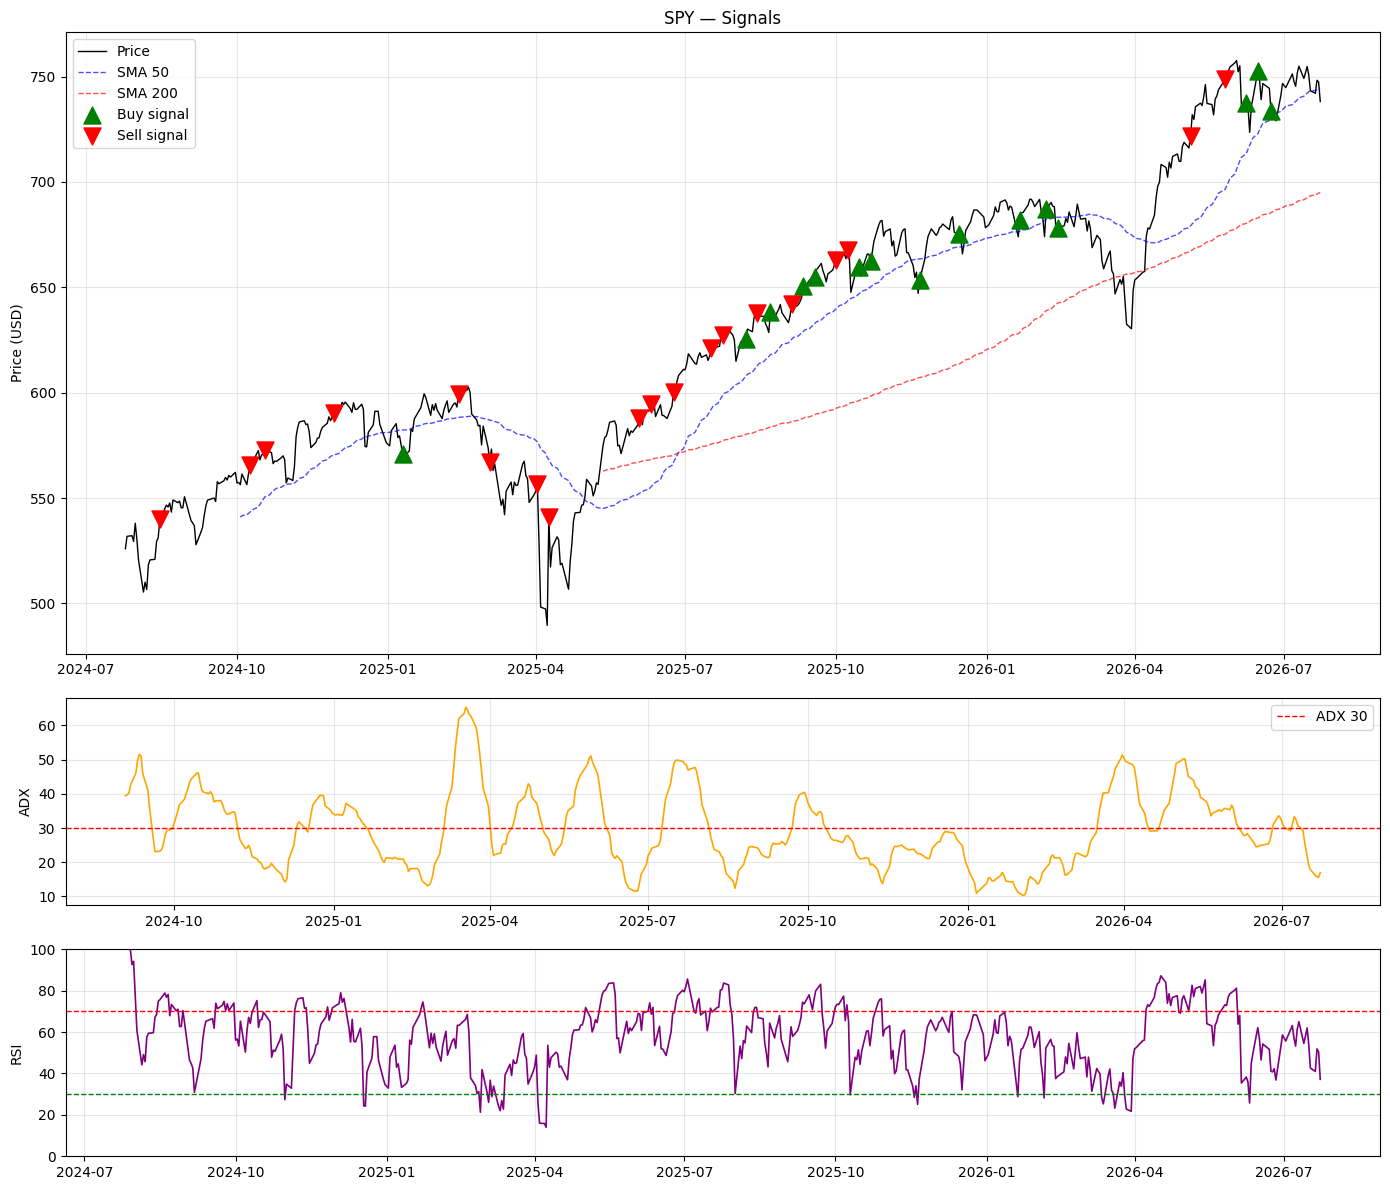

In [25]:
#now look to visualise what these functions have done, first with the places we 'should've' bought and sold according to our model
plot_signals(df, ticker)

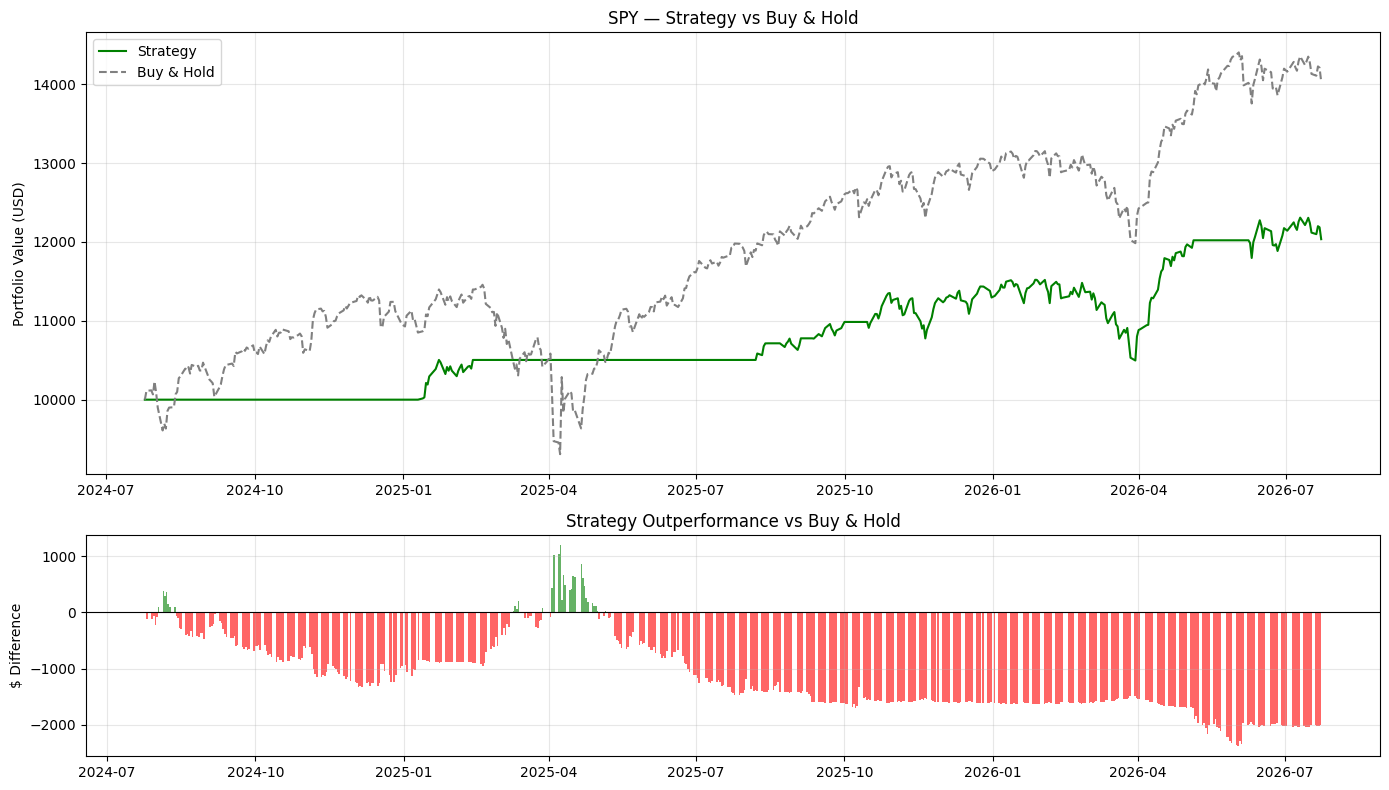

In [26]:
#now the profit/loss of doing that method, compared to just buying and holding
plot_backtest(df, ticker)

In [27]:
#now for some numerical values of whats happening above

final_strategy = df['Portfolio_Value'].iloc[-1]
final_buyhold  = df['Buy_Hold_Value'].iloc[-1]

print(f"{ticker} — Strategy vs Buy & Hold")
print(f"Strategy return:   {(final_strategy/10000 - 1)*100:.2f}%")
print(f"Buy & Hold return: {(final_buyhold/10000 - 1)*100:.2f}%")

SPY — Strategy vs Buy & Hold
Strategy return:   20.36%
Buy & Hold return: 40.35%


We now look to see about the differences between the accuracy of our model between different tickers. 

In [33]:
tickers = ["SPY", "JNJ", "SOL-USD", "TSLA"]
results = []

for tkr in tickers:
    d = fetch_price_data(tkr, period="2y", interval="1d")
    d = add_all_indicators(d)
    d = robust_composite_signal(d)
    d = backtest_signals(d)
    
    strat_ret = (d['Portfolio_Value'].iloc[-1] / 10000 - 1) * 100
    bh_ret    = (d['Buy_Hold_Value'].iloc[-1] / 10000 - 1) * 100
    
    results.append({
        'Ticker': tkr,
        'Strategy_Return_%': round(strat_ret, 2),
        'BuyHold_Return_%':  round(bh_ret, 2),
        'Outperformance_%':  round(strat_ret - bh_ret, 2)
    })

summary = pd.DataFrame(results).set_index('Ticker')
summary

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Strategy_Return_%,BuyHold_Return_%,Outperformance_%
Ticker,,,
SPY,20.36,40.35,-19.99
JNJ,73.65,71.89,1.76
SOL-USD,-26.95,-59.06,32.11
TSLA,5.74,45.15,-39.41


We see here that the outperformance varies massively based upon the tickers involved. One key reason for this is that the system does not buy when the period is started, but rather waits for a buy signal. In the case of the S&P 500, approximately half of the difference between the 2 strategies occurs in the first 6 months where no buy takes place, as the system is waiting for the first buy signal. The system is designed to detect sharp turns in the market, which we see for SOL (cryptocurrency) it does significantly better than just holding.